# Ev_4

In [120]:
# 1. Identificación y justificación de técnicas de tratamiento:
# • Expliquen cómo el tratamiento de datos faltantes asegura la integridad de los datos para su posterior uso en algoritmos de
# machine learning.
# • Presenten ejemplos de cómo la técnica seleccionada afectó positivamente el conjunto de datos procesado.
# 2. Técnicas empleadas para la normalización y estandarización con su justificación:
# • Proporcionen ejemplos de cómo el escalamiento estandarizó las variables y permitió un desempeño sin errores de los
# algoritmos.
# • Presenten visualizaciones (antes y después del escalamiento) que demuestren la transformación de los datos.
# 3. Técnicas de codificación:
# • Detallen las técnicas empleadas (Label Encoding, One-Hot Encoding, Ordinal Encoding y categorical encoding).
# • Justifiquen por qué se seleccionó una técnica específica según las características de las variables categóricas y el modelo.
# 4. Proceso de creación de nuevas variables:
# • Expliquen las técnicas aplicadas (agregaciones, transformaciones matemáticas, interacciones entre variables, etc.).
# • Justifiquen cómo estas nuevas variables aportan valor al análisis y mejoran el rendimiento del modelo.


In [121]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [122]:
df = pd.read_csv("bank-additional-full.csv", sep=';')

In [123]:
df.shape

(41188, 21)

In [124]:
df.head(2)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


Prueba inicial de modelo

In [125]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Columnas del DataFrame original
# 'age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
# 'contact', 'month', 'day_of_week', 'campaign', 'pdays', 'previous',
# 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx',
# 'euribor3m', 'nr.employed'

# Variables usadas para predecir "y"
# El modelo necesita que las variables sean numericas por lo que partimos solo con las numericas
# Mas adelante se escalaran o codificaran las variables para ver como afectan al modelo
features = ['age', 'campaign', 'pdays', 'previous',
            'emp.var.rate', 'cons.price.idx', 'cons.conf.idx',
            'euribor3m', 'nr.employed', 'duration']

df_mode = df.copy()

df_modelo, df_predi = train_test_split(
    df_mode,               # DataSet ya limpio
    test_size=0.10,         # Guarda el 10% de la data para luego predecir
    random_state=42,
    stratify=df_mode['y']  # Separa los datos de forma uniforme
)

df_train, df_test = train_test_split(
    df_modelo,              # DataSet destinado al modelo
    test_size=0.30,         # Guarda el 30% de la data para entrenar
    random_state=42,
    stratify=df_modelo['y'] # Separa los datos de forma uniforme
)

print(f"\nEntrenamiento: {len(df_train)}\nTesteo: {len(df_test)}\nPredicciones: {len(df_predi)}")

X_train = df_train[features] # features para entrenar
y_train = df_train['y']  # target para entrenar

X_test = df_test[features] # features para testear
y_test = df_test['y']  # target para testear

# Creacion de modelo de randomForestClasifier
modelo_rf = RandomForestClassifier(
    n_estimators=100    # 100 arboles
    , random_state=42
    )

modelo_rf.fit(X_train, y_train) # Se entrena el randomForest con las features y el target destinados a entrenamiento

y_pred = modelo_rf.predict(X_test) # El modelo intenta predecir el target usando las features destinadas a testeo

print("\n--- Matriz de confusion ---")
print(confusion_matrix(y_test, y_pred)) # Matriz usando el target que se uso en test y en prediccion

print("\n--- Reporte de clasificacion ---")
print(classification_report(y_test, y_pred)) # Reporte usando el target que se uso en test y en prediccion

# El modelo predice la probabilidad con x_test de que el target sea yes
# Ya que solo se toma la columna en la posicion 1
y_proba = modelo_rf.predict_proba(X_test)[:, 1]  # Probabilidad de prediccion usando todas las filas de la
                                                 # columna en la posicion 1, usando los datos de X_test
# Calcula la probabilidad de exito comparando
# el tarhet destinado a testeo y el que predijo el modelo
auc_score = roc_auc_score(y_test, y_proba)

print(f"\nAUC: {round(auc_score, 4)}")


Entrenamiento: 25948
Testeo: 11121
Predicciones: 4119

--- Matriz de confusion ---
[[9454  414]
 [ 601  652]]

--- Reporte de clasificacion ---
              precision    recall  f1-score   support

          no       0.94      0.96      0.95      9868
         yes       0.61      0.52      0.56      1253

    accuracy                           0.91     11121
   macro avg       0.78      0.74      0.76     11121
weighted avg       0.90      0.91      0.91     11121


AUC: 0.9409


Informacion de las variables

In [126]:
# campañas de marketing realizadas entre mayo de 2008 y noviembre de 2010

# 1 - edad (numerico)
# 2 - trabajo: tipo de trabajo (categorico: "administrador", "obrero", "empresario", "empleado domestico",
#     "gerente", "jubilado", "autonomo", "servicios", "estudiante", "tecnico", "desempleado", "desconocido")
# 3 - estado civil: estado civil (categorico: "divorciado", "casado", "soltero", "desconocido";
#     nota: "divorciado" significa divorciado o viudo)
# 4 - educacion (categorico: "basico.4a", "basico.6a", "basico.9a", "bachillerato", "analfabeto",
#     "curso profesional", "titulo universitario", "desconocido")
# 5 - mora: tiene credito en mora? (categorico: "no", "si­", "desconocido")
# 6 - vivienda: ¿tiene prestamo para vivienda? (categorico: "no", "si­", "desconocido")
# 7 - prestamo: ¿tiene prestamo personal? (categorico: "no", "si­", "desconocido")

# Relacionado con el ultimo contacto de la campaña actual:
# 8 - contacto: tipo de comunicacion del contacto (categorico: "celular", "telefono")
# 9 - mes: mes del año del ultimo contacto (categorico: "ene", "feb", "mar", ..., "nov", "dic")
# 10 - dia_de_la_semana: di­a de la semana del ultimo contacto (categorico: "mon", "tue", "wed", "thu", "fri")
# 11 - duracion: duracion del ultimo contacto, en segundos (numerico).
# Nota importante: este atributo afecta en gran medida el objetivo de salida
# (p. ej., si duracion=0 entonces y="no"). Sin embargo, la duracion no se conoce antes de que se realice una llamada. Ademas,
# despues del final de la llamada, obviamente se conoce y. Por lo tanto, esta entrada solo se debe incluir con fines de referencia
# y se debe descartar si la intencion es tener un modelo predictivo realista.

# Otros atributos:
# 12 - campaña: numero de contactos realizados durante esta campaña y para este cliente (numerico, incluye el ultimo contacto)
# 13 - pdays: numero de di­as transcurridos desde que el cliente fue contactado por ultima vez de una campaña anterior (numerico; 999 significa que el cliente no fue contactado previamente)
# 14 - anterior: numero de contactos realizados antes de esta campaña y para este cliente (numerico)
# 15 - poutcome: resultado de la campaña de marketing anterior (categorico: "fracaso", "inexistente", "exito")

# Atributos de contexto social y economico
# 16 - emp.var.rate: tasa de variacion del empleo - indicador trimestral (numerico)
# 17 - cons.price.idx: indice de precios al consumidor - indicador mensual (numerico)
# 18 - cons.conf.idx: i­ndice de confianza del consumidor - indicador mensual (numerico)
# 19 - euribor3m: tasa del euribor a 3 meses - indicador diario (numerico)
# 20 - nr.employed: numero de empleados

## Limpieza de variables no relevantes
* duracion

Como se menciona en la descripcion de las variables, la duracion es un dato que solo se obtiene al finalizar la llamada y al finalizarla ya se sabe el resultado de "y",por lo que se elimina para evitar el Data Leakage

In [127]:
df = df.drop(columns=['duration'])

In [128]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Columnas del DataFrame original
# 'age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
# 'contact', 'month', 'day_of_week', 'campaign', 'pdays', 'previous',
# 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx',
# 'euribor3m', 'nr.employed'

# Variables usadas para predecir "y"
# El modelo necesita que las variables sean numericas por lo que partimos solo con las numericas
# Mas adelante se escalaran o codificaran las variables para ver como afectan al modelo
features = ['age', 'campaign', 'pdays', 'previous',
            'emp.var.rate', 'cons.price.idx', 'cons.conf.idx',
            'euribor3m', 'nr.employed']

df_mode = df.copy()

df_modelo, df_predi = train_test_split(
    df_mode,               # DataSet ya limpio
    test_size=0.10,         # Guarda el 10% de la data para luego predecir
    random_state=42,
    stratify=df_mode['y']  # Separa los datos de forma uniforme
)

df_train, df_test = train_test_split(
    df_modelo,              # DataSet destinado al modelo
    test_size=0.30,         # Guarda el 30% de la data para entrenar
    random_state=42,
    stratify=df_modelo['y'] # Separa los datos de forma uniforme
)

print(f"\nEntrenamiento: {len(df_train)}\nTesteo: {len(df_test)}\nPredicciones: {len(df_predi)}")

X_train = df_train[features] # features para entrenar
y_train = df_train['y']  # target para entrenar

X_test = df_test[features] # features para testear
y_test = df_test['y']  # target para testear

# Creacion de modelo de randomForestClasifier
modelo_rf = RandomForestClassifier(
    n_estimators=100    # 100 arboles
    , random_state=42
    )

modelo_rf.fit(X_train, y_train) # Se entrena el randomForest con las features y el target destinados a entrenamiento

y_pred = modelo_rf.predict(X_test) # El modelo intenta predecir el target usando las features destinadas a testeo

print("\n--- Matriz de confusion ---")
print(confusion_matrix(y_test, y_pred)) # Matriz usando el target que se uso en test y en prediccion

print("\n--- Reporte de clasificacion ---")
print(classification_report(y_test, y_pred)) # Reporte usando el target que se uso en test y en prediccion

# El modelo predice la probabilidad con x_test de que el target sea yes
# Ya que solo se toma la columna en la posicion 1
y_proba = modelo_rf.predict_proba(X_test)[:, 1]  # Probabilidad de prediccion usando todas las filas de la
                                                 # columna en la posicion 1, usando los datos de X_test
# Calcula la probabilidad de exito comparando
# el tarhet destinado a testeo y el que predijo el modelo
auc_score = roc_auc_score(y_test, y_proba)

print(f"\nAUC: {round(auc_score, 4)}")


Entrenamiento: 25948
Testeo: 11121
Predicciones: 4119

--- Matriz de confusion ---
[[9412  456]
 [ 853  400]]

--- Reporte de clasificacion ---
              precision    recall  f1-score   support

          no       0.92      0.95      0.93      9868
         yes       0.47      0.32      0.38      1253

    accuracy                           0.88     11121
   macro avg       0.69      0.64      0.66     11121
weighted avg       0.87      0.88      0.87     11121


AUC: 0.7509


Efectivamente el AUC bajo de 0.9409 a 0.7509, lo que indica que el modelo utilizo la variable duracion para hacer trampa

## Busqueda de MV (valores nulos o bajo otros terminos como "unknow")
Lectura del dataSet clasificando MV como Nan

Listado de los valores unicos en cada variable
<br>Util para detectar valores MV que no estan definidos como Nan pero si bajo otros terminos como unknown

In [129]:
lista = df.columns.tolist()

for i in lista:
  print(i)
  print(df[i].unique())

age
[56 57 37 40 45 59 41 24 25 29 35 54 46 50 39 30 55 49 34 52 58 32 38 44
 42 60 53 47 51 48 33 31 43 36 28 27 26 22 23 20 21 61 19 18 70 66 76 67
 73 88 95 77 68 75 63 80 62 65 72 82 64 71 69 78 85 79 83 81 74 17 87 91
 86 98 94 84 92 89]
job
['housemaid' 'services' 'admin.' 'blue-collar' 'technician' 'retired'
 'management' 'unemployed' 'self-employed' 'unknown' 'entrepreneur'
 'student']
marital
['married' 'single' 'divorced' 'unknown']
education
['basic.4y' 'high.school' 'basic.6y' 'basic.9y' 'professional.course'
 'unknown' 'university.degree' 'illiterate']
default
['no' 'unknown' 'yes']
housing
['no' 'yes' 'unknown']
loan
['no' 'yes' 'unknown']
contact
['telephone' 'cellular']
month
['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'mar' 'apr' 'sep']
day_of_week
['mon' 'tue' 'wed' 'thu' 'fri']
campaign
[ 1  2  3  4  5  6  7  8  9 10 11 12 13 19 18 23 14 22 25 16 17 15 20 56
 39 35 42 28 26 27 32 21 24 29 31 30 41 37 40 33 34 43]
pdays
[999   6   4   3   5   1   0  10   7   8   9  11 

Luego de encontrar valores MV, al ser solo unknown, leemos de nuevo el dataSet marcando los unknown como nan para luego limpiar los datos

In [130]:
df = pd.read_csv("bank-additional-full.csv", sep=';', na_values='unknown')
df = df.drop(columns=['duration']) # Recordar que se elimina duracion para evitar Data Leakage

In [131]:
# Ciclo for para listar MV y su porcentaje en cada variable
for i in range(df.shape[1]):
  n_miss = int(df.iloc[:, i].isnull().sum())
  perc = round(n_miss / df.shape[0] * 100,1)
  if n_miss > 0: # Trae solo las variables con nulos, evita mostrar muchos datos inecesarios
    t = "{0} - {1}  =  Missing: {2} ({3}%)".format(i, df.columns[i], n_miss, perc)
    print(t)

1 - job  =  Missing: 330 (0.8%)
2 - marital  =  Missing: 80 (0.2%)
3 - education  =  Missing: 1731 (4.2%)
4 - default  =  Missing: 8597 (20.9%)
5 - housing  =  Missing: 990 (2.4%)
6 - loan  =  Missing: 990 (2.4%)


Ya que default y education son variables significativas porcentualmente en MV, mientras que job, marital, housing y loan, son MV porcentualmente muy bajos, como equipo consideramos analizar el tipo de MV que es education y default, para saber como imputarlos, y las demas variables imputarlas de forma simple ya que no generaran un sesgo significativo en la data

In [132]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Columnas del DataFrame original
# 'age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
# 'contact', 'month', 'day_of_week', 'campaign', 'pdays', 'previous',
# 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx',
# 'euribor3m', 'nr.employed'

# Variables usadas para predecir "y"
# El modelo necesita que las variables sean numericas por lo que partimos solo con las numericas
# Mas adelante se escalaran o codificaran las variables para ver como afectan al modelo
features = ['age', 'campaign', 'pdays', 'previous',
            'emp.var.rate', 'cons.price.idx', 'cons.conf.idx',
            'euribor3m', 'nr.employed']

df_mode = df.copy()

df_modelo, df_predi = train_test_split(
    df_mode,               # DataSet ya limpio
    test_size=0.10,         # Guarda el 10% de la data para luego predecir
    random_state=42,
    stratify=df_mode['y']  # Separa los datos de forma uniforme
)

df_train, df_test = train_test_split(
    df_modelo,              # DataSet destinado al modelo
    test_size=0.30,         # Guarda el 30% de la data para entrenar
    random_state=42,
    stratify=df_modelo['y'] # Separa los datos de forma uniforme
)

print(f"\nEntrenamiento: {len(df_train)}\nTesteo: {len(df_test)}\nPredicciones: {len(df_predi)}")

X_train = df_train[features] # features para entrenar
y_train = df_train['y']  # target para entrenar

X_test = df_test[features] # features para testear
y_test = df_test['y']  # target para testear

# Creacion de modelo de randomForestClasifier
modelo_rf = RandomForestClassifier(
    n_estimators=100    # 100 arboles
    , random_state=42
    )

modelo_rf.fit(X_train, y_train) # Se entrena el randomForest con las features y el target destinados a entrenamiento

y_pred = modelo_rf.predict(X_test) # El modelo intenta predecir el target usando las features destinadas a testeo

print("\n--- Matriz de confusion ---")
print(confusion_matrix(y_test, y_pred)) # Matriz usando el target que se uso en test y en prediccion

print("\n--- Reporte de clasificacion ---")
print(classification_report(y_test, y_pred)) # Reporte usando el target que se uso en test y en prediccion

# El modelo predice la probabilidad con x_test de que el target sea yes
# Ya que solo se toma la columna en la posicion 1
y_proba = modelo_rf.predict_proba(X_test)[:, 1]  # Probabilidad de prediccion usando todas las filas de la
                                                 # columna en la posicion 1, usando los datos de X_test
# Calcula la probabilidad de exito comparando
# el tarhet destinado a testeo y el que predijo el modelo
auc_score = roc_auc_score(y_test, y_proba)

print(f"\nAUC: {round(auc_score, 4)}")


Entrenamiento: 25948
Testeo: 11121
Predicciones: 4119

--- Matriz de confusion ---
[[9412  456]
 [ 853  400]]

--- Reporte de clasificacion ---
              precision    recall  f1-score   support

          no       0.92      0.95      0.93      9868
         yes       0.47      0.32      0.38      1253

    accuracy                           0.88     11121
   macro avg       0.69      0.64      0.66     11121
weighted avg       0.87      0.88      0.87     11121


AUC: 0.7509


El randomForest no funciona con valores nulos, ya que esto genera un error, por lo que es necesario imputar los datos, el modelo que se ejecuto arriba solo usa variables numericas, que no tienen nulos, las variables cualitativas si los tienen, poreso se probaran mas adelante junto al modelo, luego de imputarlas

## Clasificacion tipo de MV
* education(Nivel Educativo)
<br>Resultado = MAR

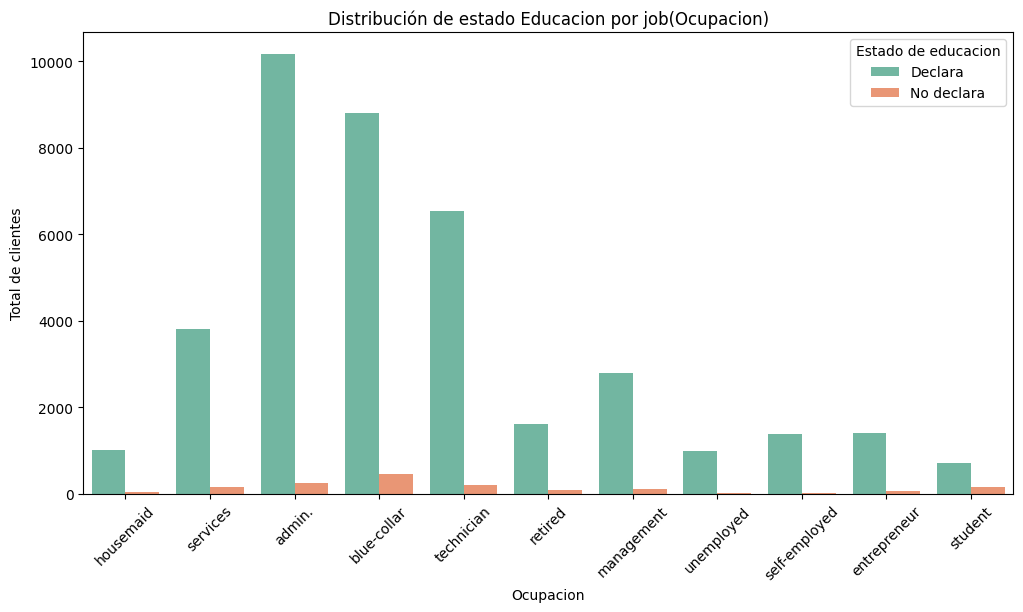

In [133]:
# se crea esta nueva columna solo para no cambiar el valor NaN a unknown o similar
df_analisis = df.copy()
df_analisis['Estado'] = df_analisis['education'].apply(lambda x: 'No declara' if True == pd.isna(x) else 'Declara') # Variable creada para separar los datos entre datos MV y no MV

plt.figure(figsize=(12, 6))
sns.countplot(data=df_analisis,
              x=f'job',
              hue='Estado',
              palette='Set2')

plt.title(f'Distribución de estado Educacion por job(Ocupacion)')
plt.ylabel("Total de clientes")
plt.xlabel(f"Ocupacion")
plt.xticks(rotation=45)
plt.legend(title='Estado de educacion')
plt.show()

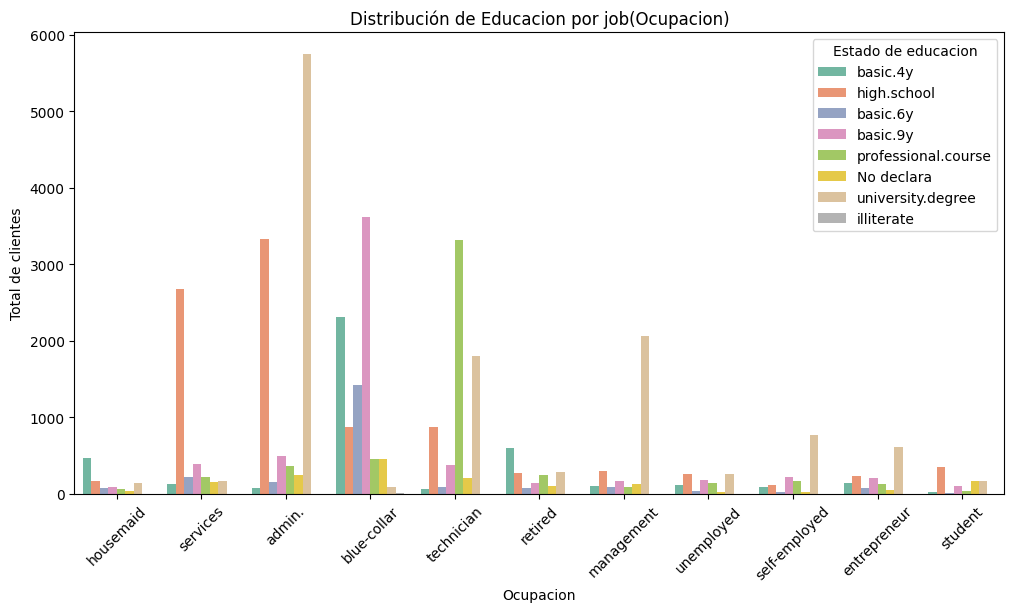

In [134]:
df_analisis = df.copy()
df_analisis['Estado'] = df_analisis['education'].apply(lambda x: 'No declara' if True == pd.isna(x) else x) # Variable creada para separar los datos entre datos MV y no MV

plt.figure(figsize=(12, 6))
sns.countplot(data=df_analisis,
              x=f'job',
              hue='Estado',
              palette='Set2')

plt.title(f'Distribución de Educacion por job(Ocupacion)')
plt.ylabel("Total de clientes")
plt.xlabel(f"Ocupacion")
plt.xticks(rotation=45)
plt.legend(title='Estado de educacion')
plt.show()

En base a que existe un nivel educativo en cada ocupacion de la variable "job", se puede deducir que la variable es de tipo MAR al tener una relacion con job, donde se asume que el cliente no ingreso su nivel educativo por verguenza a que este le de problemas en el banco, esto se puede suponer considerando que la mayor frecuencia esta marcada en blue-collar, como la clase obrera

## Clasificacion tipo de MV
* default(Morosidad)
<br>Resultado = MAR

Analisis preventivo

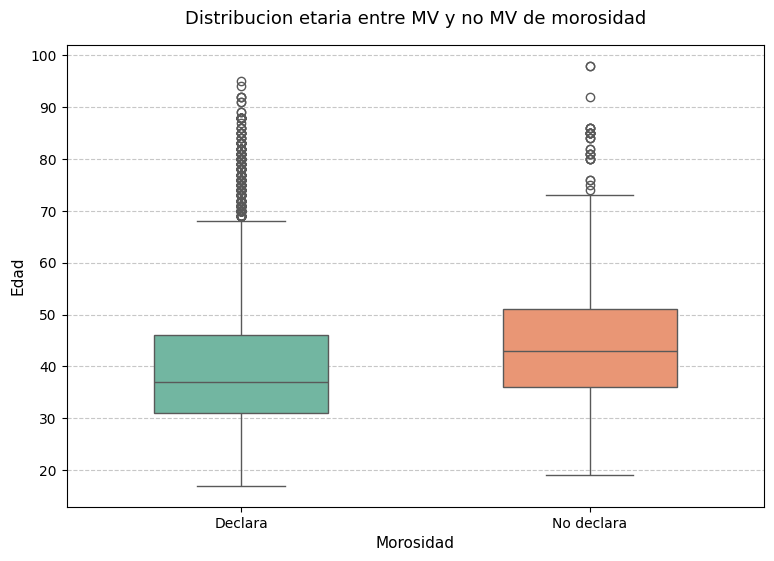

In [135]:
df_analisis = df.copy()
df_analisis['Estado'] = df_analisis['default'].apply(lambda x: 'No declara' if True == pd.isna(x) else 'Declara')

plt.figure(figsize=(9, 6))
sns.boxplot(data=df_analisis,
            x='Estado',
            y='age',
            palette='Set2',
            hue='Estado',
            width=0.5)

plt.title('Distribucion etaria entre MV y no MV de morosidad', fontsize=13, pad=15)
plt.xlabel('Morosidad', fontsize=11)
plt.ylabel('Edad', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

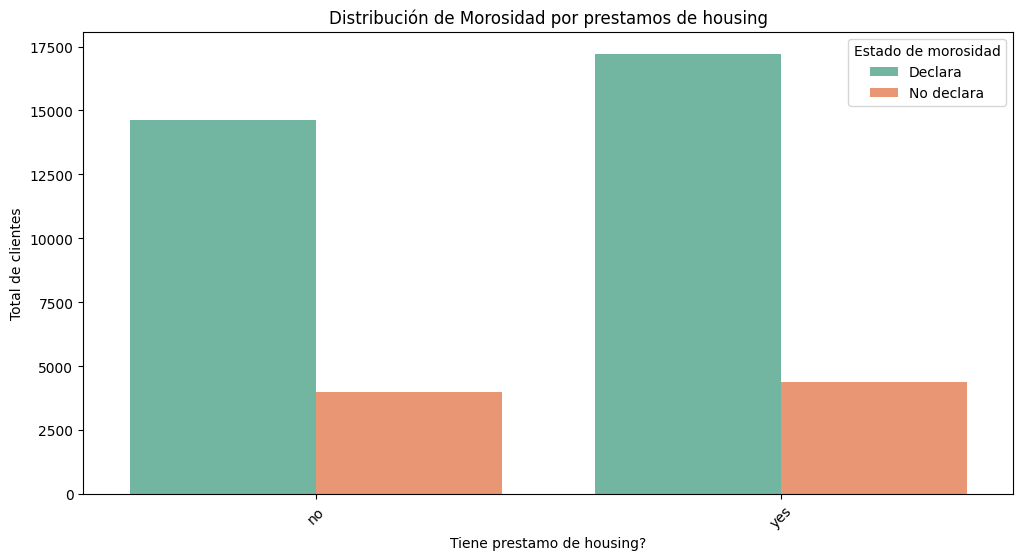

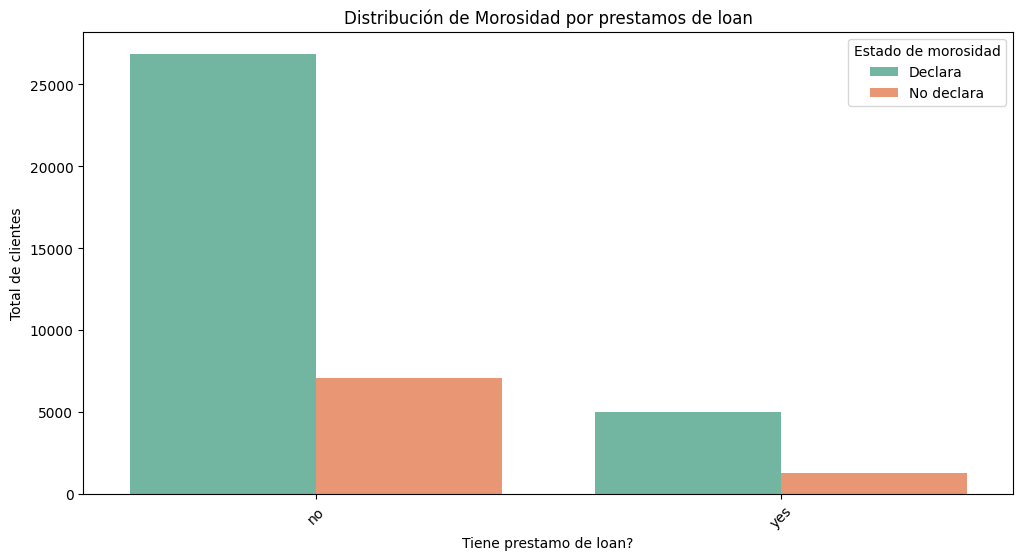

In [136]:
df_analisis = df.copy()
df_analisis['Estado'] = df_analisis['default'].apply(lambda x: 'No declara' if True == pd.isna(x) else 'Declara')
variables = ["housing", "loan"] # Variables que se descubrio que tienen relacion con default(morosidad)
for i in variables:

  plt.figure(figsize=(12, 6))
  sns.countplot(data=df_analisis,
                x=f'{i}',
                hue='Estado',
                palette='Set2')

  plt.title(f'Distribución de Morosidad por prestamos de {i}')
  plt.ylabel("Total de clientes")
  plt.xlabel(f"Tiene prestamo de {i}?")
  plt.xticks(rotation=45)
  plt.legend(title='Estado de morosidad')
  plt.show()
  print("\n")

Se puede observar que existe relacion entre morosidad y loan(prestamo personal), donde la mayoria de personas que no marco un valor en default(morosidad) no declara tener un prestamo, en cuanto a housing(prestamo de vivienda), la cantidad es equitativa, por lo que se deduce que es un MV de tipo MAR, asumiendo que aproximadamente la mitad de los clientes que no marco morosidad , se puede deber al prestamo de vivienda

## Imputacion de variables
* job
* marital
* housing
* loan

Como se menciono antes, los nulos en estas variables son un valor porcentual muy bajo por lo cual se pueden imputar de forma simple sin generar un sesgo muy grande en los modelos

In [137]:
# Se imputan los nulos en las variables, usando la moda de las mismas variables
df["job"] = df["job"].fillna(df["job"].mode()[0])
df["marital"] = df["marital"].fillna(df["marital"].mode()[0])
df["housing"] = df["housing"].fillna(df["housing"].mode()[0])
df["loan"] = df["loan"].fillna(df["loan"].mode()[0])

Verificamos que se imputaron los valores

In [138]:
# Ciclo for para listar MV y su porcentaje en cada variable
for i in range(df.shape[1]):
  n_miss = int(df.iloc[:, i].isnull().sum())
  perc = round(n_miss / df.shape[0] * 100,1)
  if n_miss > 0: # Trae solo las variables con nulos, evita mostrar muchos datos inecesarios
    t = "{0} - {1}  =  Missing: {2} ({3}%)".format(i, df.columns[i], n_miss, perc)
    print(t)

3 - education  =  Missing: 1731 (4.2%)
4 - default  =  Missing: 8597 (20.9%)


In [139]:
df.head(5)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,NaN,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## Preparacion de variables para imputacion
(Preparacion para el iterativeImputer)


Se traen las bibliotecas necesarias

In [140]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import OrdinalEncoder

# Necesario para activar el iterativeImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import ExtraTreesRegressor

In [141]:
# Solo se tomnas las variables relacionadas a los clientes, que es donde hay que imputar
df_itera = df[["age", "job", "marital", "education", "default", "housing", "loan"]].copy()

Se codifican las variables categoricas usando OrdinalEncoder para aplicarles un valor numerico que funciona como etiqueta para el iterativeImputer

In [142]:
# Solo hace falta codificar las variables categoricas ya que IterativeImputer necesita que sea un valor numerico
catColums = ['job', 'marital', 'education', 'housing', 'loan', 'default']

# Se codifican con OrdinalEncoder que permite codificar varias columnas,
# No se establece un orden jerarquico, pero hace falta para asignar un numero como etiqueta
catOrdCodifi = OrdinalEncoder(
    handle_unknown='use_encoded_value', # Valores desconocidos(Como nuevos o Nan), quedan en Nan
    unknown_value=np.nan # Los nulos quedan como nulos al codificar
    )

# Se codifican los datos para asignarles un numero a los valores
df_itera[catColums] = catOrdCodifi.fit_transform(df_itera[catColums])

## Imputacion de variables default y education a traves de iterativeImputer
(con ExtraTreesRegressor)

Por que IterativeImputer con ExtraTreeRegressor?
* Preferimos iterativeImputer por sobre otras opciones como knn, esto debido a su capacidad para tratar con datos mas caoticos ya que no es sensible a outliers como knn que calcula distancias, IterativeImputer con ExtraTreesRegressor usa arboles de decisiones que a traves de varias pruebas buscan relaciones entre las columnas para poder imputar los datos

Con las variables default y education ya preparadas, imputamos las variables usando IterativeImputer con ExtraTreesRegressor
* Funciona con un randomForest de tipo de regresion por lo cual no hace falta escalar las variables numericas
* Hace falta pasar las variables cualitativas a numericas, por eso se utiliza el ordinalEncoder, como se menciono antes, el numero funciona como "etiqueta"

In [143]:
# Se configura IterativeImputer para imputar los valores nulos
# En este caso las variables con nulos son Education y Default
impuNa = IterativeImputer(
    estimator=ExtraTreesRegressor(n_estimators=10, random_state=42), # 10 arboles
    max_iter=10, # 10 iteraciones que hace cambiando los valores nulos
    random_state=42
)

# Se imputan las variables Education y Default
df_imp = impuNa.fit_transform(df_itera)

Creacion de DataFrame con los valores imputados

In [144]:
# Se crea un nuevo dataFrame con las variables ya imputadas pero aun codificadas
df_final_itera = pd.DataFrame(
    df_imp,
    columns=df_itera.columns,
    index=df_itera.index
)

In [145]:
# Al ser un modelo de regresion, los valores pueden ser por ejemplo 2.8, se redondean para mantener
# El rango de valores con el que fue codificado, en este caso, numeros enteros, esto mantiene una eiqueta para los nulos que fueron imputados con valores decimales
df_final_itera[catColums] = df_final_itera[catColums].round().astype(int)

Recuperacion de valores en base al numero asignado a cada variable (Recuperacion de numeros strings de variables categoricas)

In [146]:
# Ahora que los valores ya no son decimales como 2.8, podemos hacer la codificacion inversa y darle
# el valor correspondiente a cada etiqueta(numero) dentro de cada variable
df_final_itera[catColums] = catOrdCodifi.inverse_transform(df_final_itera[catColums])

# Variables ya imputadas
df_final_itera.head(2)

,age,job,marital,education,default,housing,loan
0,56.0,housemaid,married,basic.4y,no,no,no
1,57.0,services,married,high.school,no,no,no


Verificamos que se imputo el valor en la fila 2 de la variable default(mora)

In [147]:
df['default'].iloc[1] # DataFrame original tiene un nulo en la fila 1 en la variable default

nan

In [148]:

df_final_itera['default'].iloc[1] # DataFrame imputado con iterativeImputer ahora tiene un'no' en la fila 1 de la variable default

'no'

In [149]:
df['education'].iloc[7]

nan

In [150]:
df_final_itera['education'].iloc[7]

'basic.6y'

Mas adelante se podra ver que education si da una mejora al modelo en cuanto al AUC, lo que indica que al final si es importante la imputacion de las variables ya que estas pueden llegar a proporcionar informacion util para el modelo, la imputacion de estos nulos pueden mejorar la precision del modelo a la hora de probar las variables ya imputadas

## Resultado de imputacion
(DataSet completo y imputado)

In [151]:
# df original sin las columnas columnas de cliente
df_origi = df.drop(columns=["age", "job", "marital", "education", "default", "housing", "loan"]).copy()
df_Imp = df_final_itera.copy()
df_clean = pd.concat([df_Imp, df_origi], axis=1)
df_clean.head(8)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56.0,housemaid,married,basic.4y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57.0,services,married,high.school,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37.0,services,married,high.school,no,yes,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40.0,admin.,married,basic.6y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56.0,services,married,high.school,no,no,yes,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
5,45.0,services,married,basic.9y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
6,59.0,admin.,married,professional.course,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
7,41.0,blue-collar,married,basic.6y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


Clientes con y sin mora

In [152]:
# DataFrame Original
clieSiMoraOrigi = df[df['default'] == "yes"]
print(f"Clientes con mora: {clieSiMoraOrigi.shape[0]}")
clieNoMoraOrigi = df[df['default'] == "no"]
print(f"Clientes sin mora: {clieNoMoraOrigi.shape[0]}")

Clientes con mora: 3
Clientes sin mora: 32588


In [153]:
# DataFrame Limpio
clieSiMoraClean = df_clean[df_clean['default'] == "yes"]
print(f"Clientes con mora: {clieSiMoraClean.shape[0]}")
clieNoMoraClean = df_clean[df_clean['default'] == "no"]
print(f"Clientes sin mora: {clieNoMoraClean.shape[0]}")

Clientes con mora: 3
Clientes sin mora: 41185


La imputacion el 20.9% de nulos en default queda con:
<br>Clientes con mora: 3 (Con 0 clientes adicionales con Mora)
<br>Clientes sin mora: 41185 (Con 8597 clientes adicionales como "sin mora")
<br>Lo que indica que todos los nulos en default(mora) eran clientes sin mora

In [154]:
for i in range(df_clean.shape[1]):
  n_miss = int(df_clean.iloc[:, i].isnull().sum())
  perc = round(n_miss / df_clean.shape[0] * 100,1)
  if n_miss > 0: # Trae solo las variables con nulos, evita mostrar muchos datos inecesarios
    t = "{0} - {1}  =  Missing: {2} ({3}%)".format(i, df_clean.columns[i], n_miss, perc)
    print(t)

In [155]:
df_clean.isna().sum()

,0
age,0
job,0
marital,0
education,0
default,0
housing,0
loan,0
contact,0
month,0
day_of_week,0


Ya no hay mas variables con valores Nulos

Esta parte es muy importante ya que el randomForest como se menciono en un inicio, falla si se prueba con variables con Nulos (Nan), por lo que la imputacion nos permite probar las demas variables en el modelo y ver como le afectan

## Analisis comparativos

In [156]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler

Ahora que el DataSet ya esta imputado vamos a ver como le afecta la informacion limpia al modelo
<br>Comenzamos con las variables numericas relacionadas a los clientes, ya que al variar tanto por cliente es muy probable que tengan outliers

In [157]:
variNumeri = ['age', 'campaign', 'pdays', 'previous']

for i in variNumeri:
  q1 = df_clean[i].quantile(0.25)
  q3 = df_clean[i].quantile(0.75)
  iqr = q3 - q1 # Rango interquantil
  outMin = q1 - 1.5 * iqr # Outliers menores
  outMax = q3 + 1.5 * iqr # Outliers mayores
  outliers = df_clean[(df_clean[i] < outMin) | (df_clean[i] > outMax)]
  print(f"Variable: {i}")
  print(f"Outliers: {outliers.shape[0]}")
  print("\n")

Variable: age
Outliers: 469


Variable: campaign
Outliers: 2406


Variable: pdays
Outliers: 1515


Variable: previous
Outliers: 5625




Efectivamente tienen outliers, vamos a ver como le afectan al modelo una por una
escaladas con robustScaler para evitar los outliers
<br>(Cabe recalcar que a un randomForestClassifier, en lo teorico, no le afectan los valores atipicos, ya que solo busca el punto optimo donde hacer un corte, igualmente se comprobaran las variables escaladas para ver si se presenta alguna mejora)

In [158]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [159]:
robust = ['age', 'campaign', 'pdays', 'previous']
robScal = RobustScaler()

for i in robust:
  print("\n"+"- "*7+f"Variable escalada con RobustScaler : {i}"+" -"*7)
  # Variables usadas para predecir "y"
  features = ['age', 'campaign', 'pdays', 'previous',
              'emp.var.rate', 'cons.price.idx', 'cons.conf.idx',
              'euribor3m', 'nr.employed']

  df_mode = df_clean.copy()
  df_mode[i] = robScal.fit_transform(df_mode[[i]])

  df_modelo, df_predi = train_test_split(
      df_mode,               # DataSet ya limpio
      test_size=0.10,         # Guarda el 10% de la data para luego predecir
      random_state=42,
      stratify=df_mode['y']  # Separa los datos de forma uniforme
  )

  df_train, df_test = train_test_split(
      df_modelo,              # DataSet destinado al modelo
      test_size=0.30,         # Guarda el 30% de la data para entrenar
      random_state=42,
      stratify=df_modelo['y'] # Separa los datos de forma uniforme
  )

  print(f"\nEntrenamiento: {len(df_train)}\nTesteo: {len(df_test)}\nPredicciones: {len(df_predi)}")

  X_train = df_train[features] # features para entrenar
  y_train = df_train['y']  # target para entrenar

  X_test = df_test[features] # features para testear
  y_test = df_test['y']  # target para testear

  # Creacion de modelo de randomForestClasifier
  modelo_rf = RandomForestClassifier(
      n_estimators=100    # 100 arboles
      , random_state=42
      )

  modelo_rf.fit(X_train, y_train) # Se entrena el randomForest con las features y el target destinados a entrenamiento

  y_pred = modelo_rf.predict(X_test) # El modelo intenta predecir el target usando las features destinadas a testeo

  print("\n--- Matriz de confusion ---")
  print(confusion_matrix(y_test, y_pred)) # Matriz usando el target que se uso en test y en prediccion

  print("\n--- Reporte de clasificacion ---")
  print(classification_report(y_test, y_pred)) # Reporte usando el target que se uso en test y en prediccion

  # El modelo predice la probabilidad con x_test de que el target sea yes
  # Ya que solo se toma la columna en la posicion 1
  y_proba = modelo_rf.predict_proba(X_test)[:, 1]  # Probabilidad de prediccion usando todas las filas de la
                                                  # columna en la posicion 1, usando los datos de X_test
  # Calcula la probabilidad de exito comparando
  # el tarhet destinado a testeo y el que predijo el modelo
  auc_score = roc_auc_score(y_test, y_proba)

  print(f"\nAUC: {round(auc_score, 4)}")


- - - - - - - Variable escalada con RobustScaler : age - - - - - - -

Entrenamiento: 25948
Testeo: 11121
Predicciones: 4119

--- Matriz de confusion ---
[[9411  457]
 [ 850  403]]

--- Reporte de clasificacion ---
              precision    recall  f1-score   support

          no       0.92      0.95      0.94      9868
         yes       0.47      0.32      0.38      1253

    accuracy                           0.88     11121
   macro avg       0.69      0.64      0.66     11121
weighted avg       0.87      0.88      0.87     11121


AUC: 0.7511

- - - - - - - Variable escalada con RobustScaler : campaign - - - - - - -

Entrenamiento: 25948
Testeo: 11121
Predicciones: 4119

--- Matriz de confusion ---
[[9412  456]
 [ 853  400]]

--- Reporte de clasificacion ---
              precision    recall  f1-score   support

          no       0.92      0.95      0.93      9868
         yes       0.47      0.32      0.38      1253

    accuracy                           0.88     11121
   macr

En el aterior modelo el AUC fue de 0.7509
<br>Y como se puede observar, escalar con RobustScaler las variables numericas mencionadas, no tiene cambios en el resultado final ya que al modelo no le afectan los outliers

Ahora probaremos a escalar las otras variables numericas con StandardScaler ya que el modelo no exige que sea un rango estricto de 0 y 1 por lo cual no hace falta MinMax, por otra parte, StandardScaler sirve para ver como alejan los datos de la variable en base a su media
<br>Esto en teoria, tampoco afectara al randomForest, ya que al ser un modelo que busca el corte mas efectivo, ocurrira lo mismo con los datos escalados

In [160]:
standard = ['emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
standScal = StandardScaler()

for i in standard:
  print("\n"+"- "*7+f"Variable escalada con StandardScaler : {i}"+" -"*7)
  # Variables usadas para predecir "y"
  features = ['age', 'campaign', 'pdays', 'previous',
              'emp.var.rate', 'cons.price.idx', 'cons.conf.idx',
              'euribor3m', 'nr.employed']

  df_mode = df_clean.copy()
  df_mode[i] = standScal.fit_transform(df_mode[[i]])

  df_modelo, df_predi = train_test_split(
      df_mode,               # DataSet ya limpio
      test_size=0.10,         # Guarda el 10% de la data para luego predecir
      random_state=42,
      stratify=df_mode['y']  # Separa los datos de forma uniforme
  )

  df_train, df_test = train_test_split(
      df_modelo,              # DataSet destinado al modelo
      test_size=0.30,         # Guarda el 30% de la data para entrenar
      random_state=42,
      stratify=df_modelo['y'] # Separa los datos de forma uniforme
  )

  print(f"\nEntrenamiento: {len(df_train)}\nTesteo: {len(df_test)}\nPredicciones: {len(df_predi)}")

  X_train = df_train[features] # features para entrenar
  y_train = df_train['y']  # target para entrenar

  X_test = df_test[features] # features para testear
  y_test = df_test['y']  # target para testear

  # Creacion de modelo de randomForestClasifier
  modelo_rf = RandomForestClassifier(
      n_estimators=100    # 100 arboles
      , random_state=42
      )

  modelo_rf.fit(X_train, y_train) # Se entrena el randomForest con las features y el target destinados a entrenamiento

  y_pred = modelo_rf.predict(X_test) # El modelo intenta predecir el target usando las features destinadas a testeo

  print("\n--- Matriz de confusion ---")
  print(confusion_matrix(y_test, y_pred)) # Matriz usando el target que se uso en test y en prediccion

  print("\n--- Reporte de clasificacion ---")
  print(classification_report(y_test, y_pred)) # Reporte usando el target que se uso en test y en prediccion

  # El modelo predice la probabilidad con x_test de que el target sea yes
  # Ya que solo se toma la columna en la posicion 1
  y_proba = modelo_rf.predict_proba(X_test)[:, 1]  # Probabilidad de prediccion usando todas las filas de la
                                                  # columna en la posicion 1, usando los datos de X_test
  # Calcula la probabilidad de exito comparando
  # el tarhet destinado a testeo y el que predijo el modelo
  auc_score = roc_auc_score(y_test, y_proba)

  print(f"\nAUC: {round(auc_score, 4)}")


- - - - - - - Variable escalada con StandardScaler : emp.var.rate - - - - - - -

Entrenamiento: 25948
Testeo: 11121
Predicciones: 4119

--- Matriz de confusion ---
[[9412  456]
 [ 853  400]]

--- Reporte de clasificacion ---
              precision    recall  f1-score   support

          no       0.92      0.95      0.93      9868
         yes       0.47      0.32      0.38      1253

    accuracy                           0.88     11121
   macro avg       0.69      0.64      0.66     11121
weighted avg       0.87      0.88      0.87     11121


AUC: 0.7509

- - - - - - - Variable escalada con StandardScaler : cons.price.idx - - - - - - -

Entrenamiento: 25948
Testeo: 11121
Predicciones: 4119

--- Matriz de confusion ---
[[9412  456]
 [ 853  400]]

--- Reporte de clasificacion ---
              precision    recall  f1-score   support

          no       0.92      0.95      0.93      9868
         yes       0.47      0.32      0.38      1253

    accuracy                           0.8

En el aterior modelo el AUC fue de 0.7509
<br>Y como se puede observar, escalar con StandardScaler las variables numericas mencionadas, no tiene cambios en el resultado final ya que al modelo no le afecta si las variables estan escaladas con StandardScaler o no

Seguimos con las variables culitativas ordinales, a estas se les aplicara OrdinalEncoder que segun el orden que se le de para cada variable, cada valor dentro de la variable tendra un valor numerico que puede poner a un valor como mas importante que otro, esto segun el orden jerarquico,
esto es importante tambien ya que el modelo necesita que las variables cualitativas esten como valores numericos
<br>Vamos a ver como le afecta al modelo la adicion de estas variables

In [161]:
# Variables Cualitativas ordinales
ordinal = ['education', 'month', 'day_of_week']

ordEdu = ['illiterate', 'basic.4y', 'basic.6y', 'basic.9y',
          'high.school', 'professional.course', 'university.degree'] # Orden de education
ordMonth = ['mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec'] # Orden de month
ordDay = ['mon', 'tue', 'wed', 'thu', 'fri'] # Orden day_of_week

aucModelAnteri = 0.7509 # AUC del modelo antrior

for i in ordinal:
  print("\n"+"- "*7+f"Variable codificada con OrdinalEncoder : {i}"+" -"*7)
  # Condificones if para hacer el OrdinalEncoder
  # con el orden de la variable correspondiente
  if i == 'education':
    ordCodifi = OrdinalEncoder(
    categories=[ordEdu]
    )
  if i == 'month':
    ordCodifi = OrdinalEncoder(
    categories=[ordMonth]
    )
  if i == 'day_of_week':
    ordCodifi = OrdinalEncoder(
    categories=[ordDay]
    )

  # Variables usadas para predecir "y"
  features = ['age', 'campaign', 'pdays', 'previous',
              'emp.var.rate', 'cons.price.idx', 'cons.conf.idx',
              'euribor3m', 'nr.employed', f'{i}']

  df_mode = df_clean.copy()
  df_mode[i] = ordCodifi.fit_transform(df_mode[[i]])

  df_modelo, df_predi = train_test_split(
      df_mode,               # DataSet ya limpio
      test_size=0.10,         # Guarda el 10% de la data para luego predecir
      random_state=42,
      stratify=df_mode['y']  # Separa los datos de forma uniforme
  )

  df_train, df_test = train_test_split(
      df_modelo,              # DataSet destinado al modelo
      test_size=0.30,         # Guarda el 30% de la data para entrenar
      random_state=42,
      stratify=df_modelo['y'] # Separa los datos de forma uniforme
  )

  print(f"\nEntrenamiento: {len(df_train)}\nTesteo: {len(df_test)}\nPredicciones: {len(df_predi)}")

  X_train = df_train[features] # features para entrenar
  y_train = df_train['y']  # target para entrenar

  X_test = df_test[features] # features para testear
  y_test = df_test['y']  # target para testear

  # Creacion de modelo de randomForestClasifier
  modelo_rf = RandomForestClassifier(
      n_estimators=100    # 100 arboles
      , random_state=42
      )

  modelo_rf.fit(X_train, y_train) # Se entrena el randomForest con las features y el target destinados a entrenamiento

  y_pred = modelo_rf.predict(X_test) # El modelo intenta predecir el target usando las features destinadas a testeo

  print("\n--- Matriz de confusion ---")
  print(confusion_matrix(y_test, y_pred)) # Matriz usando el target que se uso en test y en prediccion

  print("\n--- Reporte de clasificacion ---")
  print(classification_report(y_test, y_pred)) # Reporte usando el target que se uso en test y en prediccion

  # El modelo predice la probabilidad con x_test de que el target sea yes
  # Ya que solo se toma la columna en la posicion 1
  y_proba = modelo_rf.predict_proba(X_test)[:, 1]  # Probabilidad de prediccion usando todas las filas de la
                                                  # columna en la posicion 1, usando los datos de X_test
  # Calcula la probabilidad de exito comparando
  # el tarhet destinado a testeo y el que predijo el modelo
  auc_score = roc_auc_score(y_test, y_proba)

  print(f"\nAUC: {round(auc_score, 3)}")
  print(f"\nAUC de los anteriores modelos: {aucModelAnteri}")
  print(f"\nCambio en el AUC de: {round(auc_score - aucModelAnteri, 3)}")


- - - - - - - Variable codificada con OrdinalEncoder : education - - - - - - -

Entrenamiento: 25948
Testeo: 11121
Predicciones: 4119

--- Matriz de confusion ---
[[9414  454]
 [ 872  381]]

--- Reporte de clasificacion ---
              precision    recall  f1-score   support

          no       0.92      0.95      0.93      9868
         yes       0.46      0.30      0.36      1253

    accuracy                           0.88     11121
   macro avg       0.69      0.63      0.65     11121
weighted avg       0.86      0.88      0.87     11121


AUC: 0.758

AUC de los anteriores modelos: 0.7509

Cambio en el AUC de: 0.007

- - - - - - - Variable codificada con OrdinalEncoder : month - - - - - - -

Entrenamiento: 25948
Testeo: 11121
Predicciones: 4119

--- Matriz de confusion ---
[[9425  443]
 [ 866  387]]

--- Reporte de clasificacion ---
              precision    recall  f1-score   support

          no       0.92      0.96      0.94      9868
         yes       0.47      0.31      

Ya que month solo mejora en un 0.001 el AUC, al ser un valor tan bajo no se incluira, pero las otras 2 variables si, ya que al ser de 0.005 y 0.007 pueden ser un poco mas utiles para el modelo

In [162]:
# Variables Cualitativas ordinales
# Ya que las siguientes variables cualitativas si tienen un orden jerarquico, se utiliza OrdinalEncoder
# para darles un orden , asignandoles valores de 0 a N que es lo que hace ordinalEncoder segun el orden asignado,
# haciendo que un valor tenga mas peso que otro segun el orden jerarquico en las variables
# Educacion tiene un orden jerarquico desde analfabeto a titulo universitario
# Dia de la semana, tiene el clasico orden jerarquico de luneas a viernes, no tiene ni sabado ni domingo
ordinal = ['education', 'day_of_week']

ordEdu = ['illiterate', 'basic.4y', 'basic.6y', 'basic.9y',
          'high.school', 'professional.course', 'university.degree'] # Orden de education

ordMonth = ['mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec'] # Orden de month

ordDay = ['mon', 'tue', 'wed', 'thu', 'fri'] # Orden day_of_week


ordCodifi = OrdinalEncoder(
  categories=[ordEdu, ordDay]
  )

# Variables usadas para predecir "y"
features = ['age', 'campaign', 'pdays', 'previous',
            'emp.var.rate', 'cons.price.idx', 'cons.conf.idx',
            'euribor3m', 'nr.employed', 'education', 'day_of_week']

df_mode = df_clean.copy()
df_mode[['education', 'day_of_week']] = ordCodifi.fit_transform(df_mode[['education', 'day_of_week']])

df_modelo, df_predi = train_test_split(
    df_mode,               # DataSet ya limpio
    test_size=0.10,         # Guarda el 10% de la data para luego predecir
    random_state=42,
    stratify=df_mode['y']  # Separa los datos de forma uniforme
)

df_train, df_test = train_test_split(
    df_modelo,              # DataSet destinado al modelo
    test_size=0.30,         # Guarda el 30% de la data para entrenar
    random_state=42,
    stratify=df_modelo['y'] # Separa los datos de forma uniforme
)

print(f"\nEntrenamiento: {len(df_train)}\nTesteo: {len(df_test)}\nPredicciones: {len(df_predi)}")

X_train = df_train[features] # features para entrenar
y_train = df_train['y']  # target para entrenar

X_test = df_test[features] # features para testear
y_test = df_test['y']  # target para testear

# Creacion de modelo de randomForestClasifier
modelo_rf = RandomForestClassifier(
    n_estimators=100    # 100 arboles
    , random_state=42
    )

modelo_rf.fit(X_train, y_train) # Se entrena el randomForest con las features y el target destinados a entrenamiento

y_pred = modelo_rf.predict(X_test) # El modelo intenta predecir el target usando las features destinadas a testeo

print("\n--- Matriz de confusion ---")
print(confusion_matrix(y_test, y_pred)) # Matriz usando el target que se uso en test y en prediccion

print("\n--- Reporte de clasificacion ---")
print(classification_report(y_test, y_pred)) # Reporte usando el target que se uso en test y en prediccion

# El modelo predice la probabilidad con x_test de que el target sea yes
# Ya que solo se toma la columna en la posicion 1
y_proba = modelo_rf.predict_proba(X_test)[:, 1]  # Probabilidad de prediccion usando todas las filas de la
                                                # columna en la posicion 1, usando los datos de X_test
# Calcula la probabilidad de exito comparando
# el tarhet destinado a testeo y el que predijo el modelo
auc_score = roc_auc_score(y_test, y_proba)

print(f"\nAUC: {round(auc_score, 3)}")
print(f"\nAUC de los anteriores modelos: {aucModelAnteri}")


Entrenamiento: 25948
Testeo: 11121
Predicciones: 4119

--- Matriz de confusion ---
[[9438  430]
 [ 854  399]]

--- Reporte de clasificacion ---
              precision    recall  f1-score   support

          no       0.92      0.96      0.94      9868
         yes       0.48      0.32      0.38      1253

    accuracy                           0.88     11121
   macro avg       0.70      0.64      0.66     11121
weighted avg       0.87      0.88      0.87     11121


AUC: 0.762

AUC de los anteriores modelos: 0.7509


El AUC subio a 0.762, el modelo va mejorando

Ahora añadimos las otras variables categoricas, las siguienes variables no tienen un orden jerarquico por lo que que se usara OneHotEncoder
<br>OneHotEncoder es el indicado ya que por cada valor diferente dentro de la misma variable, crea una columna marcando todos los valores con un 0, y con un 1 el valor correspodniente a cada fila dentro de esa variable, asi un valor no tiene una importancia mayor que otro valor dentro de la misma variable

Se utilizara un pipeline con las columnas antes vistas y las nuevas a probar, esto con el fin de usar una Matriz Dispersa que es lo que OneHotEncoder entrega por defecto, esto con el fin de evitar multiples 0 por el uso de OneHotEncoder
<br>Lo que entrega por defecto OneHotEncoder son las posiciones de donde esta un 1, indicando columna, fila, y luego de cuantos 0 hay un 1

In [163]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [164]:
variNume = ['age', 'campaign', 'pdays', 'previous', 'emp.var.rate',
            'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

# Ya que las siguientes variables cualitativas si tienen un orden jerarquico, se utiliza OrdinalEncoder
# para darles un orden , asignandoles valores de 0 a N que es lo que hace ordinalEncoder segun el orden asignado,
# haciendo que un valor tenga mas peso que otro segun el orden jerarquico en las variables
# Educacion tiene un orden jerarquico desde analfabeto a titulo universitario
# Dia de la semana, tiene el clasico orden jerarquico de luneas a viernes, no tiene ni sabado ni domingo
ordinal = ['education', 'day_of_week']

ordEdu = ['illiterate', 'basic.4y', 'basic.6y', 'basic.9y',
          'high.school', 'professional.course', 'university.degree'] # Orden de education
ordDay = ['mon', 'tue', 'wed', 'thu', 'fri'] # Orden day_of_week

ordGeneral = [ordEdu, ordDay] # Orden de las variables cualitativas Ordinales

# Creando objeto de ordinalEncoder
ordEncoder = OrdinalEncoder(
    categories=ordGeneral
    )

# Al ser variables categoricas nominales, es decir, sin un orden jerarquico, se utiliza OneHotEncoder
# Esto ya que OneHotEncoder crea columnas por cada valor dentro de la columna
# Aplicando un 1 al valor correspondiente en cada fila y un 0 a los demas valores
# Lo que hace que un valor no tengas mas peso que otro
onehot = ['job', 'marital', 'default', 'housing', 'loan', 'contact', 'poutcome']

aucModelAnteri = 0.762 # AUC del modelo anterior

for i in onehot:
  print("\n"+"- "*7+f"Variable codificada con OneHotEncoder : {i}"+" -"*7)
  # Condificones if para hacer el OrdinalEncoder
  # con el orden de la variable correspondiente

  # Variables usadas para predecir "y"
  features = ['age', 'campaign', 'pdays', 'previous',
              'emp.var.rate', 'cons.price.idx', 'cons.conf.idx',
              'euribor3m', 'nr.employed', 'education',
              'day_of_week', f'{i}']

  df_mode = df_clean.drop(columns=['month']).copy()

  df_modelo, df_predi = train_test_split(
      df_mode,               # DataSet ya limpio
      test_size=0.10,         # Guarda el 10% de la data para luego predecir
      random_state=42,
      stratify=df_mode['y']  # Separa los datos de forma uniforme
  )

  df_train, df_test = train_test_split(
      df_modelo,              # DataSet destinado al modelo
      test_size=0.30,         # Guarda el 30% de la data para entrenar
      random_state=42,
      stratify=df_modelo['y'] # Separa los datos de forma uniforme
  )

  print(f"\nEntrenamiento: {len(df_train)}\nTesteo: {len(df_test)}\nPredicciones: {len(df_predi)}")

  X_train = df_train[features] # features para entrenar
  y_train = df_train['y']  # target para entrenar

  X_test = df_test[features] # features para testear
  y_test = df_test['y']  # target para testear

  pipeline = ColumnTransformer(transformers=[
    ('num', 'passthrough', variNume),
    ('ordinal', ordEncoder, ordinal), # Variables codificadas con OrdinalEncoder
    ('oneHot', OneHotEncoder(), [i]) # Variables codificadas con OneHotEncoder
  ])

  X_train_pipe = pipeline.fit_transform(X_train)
  X_test_pipe = pipeline.transform(X_test)

  # Creacion de modelo de randomForestClasifier
  modelo_rf = RandomForestClassifier(
      n_estimators=100    # 100 arboles
      , random_state=42
      )

  modelo_rf.fit(X_train_pipe, y_train) # Se entrena el randomForest con las features y el target destinados a entrenamiento

  y_pred = modelo_rf.predict(X_test_pipe) # El modelo intenta predecir el target usando las features destinadas a testeo

  print("\n--- Matriz de confusion ---")
  print(confusion_matrix(y_test, y_pred)) # Matriz usando el target que se uso en test y en prediccion

  print("\n--- Reporte de clasificacion ---")
  print(classification_report(y_test, y_pred)) # Reporte usando el target que se uso en test y en prediccion

  # El modelo predice la probabilidad con x_test de que el target sea yes
  # Ya que solo se toma la columna en la posicion 1
  y_proba = modelo_rf.predict_proba(X_test_pipe)[:, 1]  # Probabilidad de prediccion usando todas las filas de la
                                                  # columna en la posicion 1, usando los datos de X_test
  # Calcula la probabilidad de exito comparando
  # el tarhet destinado a testeo y el que predijo el modelo
  auc_score = roc_auc_score(y_test, y_proba)

  print(f"\nAUC: {round(auc_score, 3)}")
  print(f"\nAUC de los anteriores modelos: {aucModelAnteri}")
  print(f"\nCambio en el AUC de: {round(auc_score - aucModelAnteri, 3)}")


- - - - - - - Variable codificada con OneHotEncoder : job - - - - - - -

Entrenamiento: 25948
Testeo: 11121
Predicciones: 4119

--- Matriz de confusion ---
[[9487  381]
 [ 860  393]]

--- Reporte de clasificacion ---
              precision    recall  f1-score   support

          no       0.92      0.96      0.94      9868
         yes       0.51      0.31      0.39      1253

    accuracy                           0.89     11121
   macro avg       0.71      0.64      0.66     11121
weighted avg       0.87      0.89      0.88     11121


AUC: 0.763

AUC de los anteriores modelos: 0.762

Cambio en el AUC de: 0.001

- - - - - - - Variable codificada con OneHotEncoder : marital - - - - - - -

Entrenamiento: 25948
Testeo: 11121
Predicciones: 4119

--- Matriz de confusion ---
[[9456  412]
 [ 863  390]]

--- Reporte de clasificacion ---
              precision    recall  f1-score   support

          no       0.92      0.96      0.94      9868
         yes       0.49      0.31      0.38   

Ya que todas las variables dieron 0.002 como maximo, no se incluiran en el modelo las variables codificadas con OneHotEncoder

RECORDAR : Tal como se mostro al inicio el randomForest funcionaba con nulos, pero ahora se puede ver que luego de imputar, algunas de las variables imputadas si aportaron mejoras al modelo, mostrando que la imputacion en variables si fue necesaria

## Feature Engineering

Creacion de columna nueva "año"

Tal como se menciona en la informacion del DataSet
<br>"bank-additional-full.csv con todos los ejemplos, ordenados por fecha (desde mayo de 2008 hasta noviembre de 2010)."
<br>Los datos estan ordenados por fecha, por lo cual como columna adicional crearemo la columna "año", que sirve para realizar graficos para ver como se distribuyen los datos durante los años y encontrar relaciones

In [165]:
# Ya que la lista esta ordenada, y solo falta el mes de septiembre en el año 2008
# Se usa el mes de diciembre como un "corte", que indica que hay que aumentar en
# 1 el año, llegando hasta el año 2010
meses = df_clean['month'].tolist() # Se pasan los meses a lista
anio = [] # Lista donde se guardaran los años
ani = 2008 # año de inicio
corte = 0 # Se cambia a 1 al llegar a diciembre, ya que es el ultimo mes del año
for i in meses: # se recorren los meses
  if i == "dec":
    corte = 1  # Si el mes es diciembre se cambia a 1 el corte
  if corte == 1 and i != "dec": # Si el corte esta en 1 y el mes de diciembre cambia
    ani += 1                    # Se le suma 1 al año inicial para los meses despues de diciembre
    corte = 0 # Se reinicia el corte
  anio.append(ani) # Se añaden los años
df_clean["anio"] = anio # Se crea la columna año

Ahora verificamos que la primera fila sea 2008 y la ultima 2010

In [166]:
df_clean.head(1)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,anio
0,56.0,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,2008


In [167]:
df_clean.tail(1)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,anio
41187,74.0,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,999,1,failure,-1.1,94.767,-50.8,1.028,4963.6,no,2010


La columna de año se creo con exito, ahora vamos a verificar su impacto en el modelo

In [168]:
# Variables Cualitativas ordinales
# Ya que las siguientes variables cualitativas si tienen un orden jerarquico, se utiliza OrdinalEncoder
# para darles un orden , asignandoles valores de 0 a N que es lo que hace ordinalEncoder segun el orden asignado,
# haciendo que un valor tenga mas peso que otro segun el orden jerarquico en las variables
# Educacion tiene un orden jerarquico desde analfabeto a titulo universitario
# Dia de la semana, tiene el clasico orden jerarquico de luneas a viernes, no tiene ni sabado ni domingo
ordinal = ['education', 'day_of_week']

ordEdu = ['illiterate', 'basic.4y', 'basic.6y', 'basic.9y',
          'high.school', 'professional.course', 'university.degree'] # Orden de education

ordMonth = ['mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec'] # Orden de month

ordDay = ['mon', 'tue', 'wed', 'thu', 'fri'] # Orden day_of_week


ordCodifi = OrdinalEncoder(
  categories=[ordEdu, ordDay]
  )

# Variables usadas para predecir "y"
features = ['age', 'campaign', 'pdays', 'previous',
            'emp.var.rate', 'cons.price.idx', 'cons.conf.idx',
            'euribor3m', 'nr.employed', 'education', 'day_of_week', 'anio']

df_mode = df_clean.drop(columns=['month']).copy()
df_mode[['education', 'day_of_week']] = ordCodifi.fit_transform(df_mode[['education', 'day_of_week']])

df_modelo, df_predi = train_test_split(
    df_mode,               # DataSet ya limpio
    test_size=0.10,         # Guarda el 10% de la data para luego predecir
    random_state=42,
    stratify=df_mode['y']  # Separa los datos de forma uniforme
)

df_train, df_test = train_test_split(
    df_modelo,              # DataSet destinado al modelo
    test_size=0.30,         # Guarda el 30% de la data para entrenar
    random_state=42,
    stratify=df_modelo['y'] # Separa los datos de forma uniforme
)

print(f"\nEntrenamiento: {len(df_train)}\nTesteo: {len(df_test)}\nPredicciones: {len(df_predi)}")

X_train = df_train[features] # features para entrenar
y_train = df_train['y']  # target para entrenar

X_test = df_test[features] # features para testear
y_test = df_test['y']  # target para testear

# Creacion de modelo de randomForestClasifier
modelo_rf = RandomForestClassifier(
    n_estimators=100    # 100 arboles
    , random_state=42
    )

modelo_rf.fit(X_train, y_train) # Se entrena el randomForest con las features y el target destinados a entrenamiento

y_pred = modelo_rf.predict(X_test) # El modelo intenta predecir el target usando las features destinadas a testeo

print("\n--- Matriz de confusion ---")
print(confusion_matrix(y_test, y_pred)) # Matriz usando el target que se uso en test y en prediccion

print("\n--- Reporte de clasificacion ---")
print(classification_report(y_test, y_pred)) # Reporte usando el target que se uso en test y en prediccion

# El modelo predice la probabilidad con x_test de que el target sea yes
# Ya que solo se toma la columna en la posicion 1
y_proba = modelo_rf.predict_proba(X_test)[:, 1]  # Probabilidad de prediccion usando todas las filas de la
                                                # columna en la posicion 1, usando los datos de X_test
# Calcula la probabilidad de exito comparando
# el tarhet destinado a testeo y el que predijo el modelo
auc_score = roc_auc_score(y_test, y_proba)

print(f"\nAUC: {round(auc_score, 3)}")
print(f"\nAUC de los anteriores modelos: {aucModelAnteri}")


Entrenamiento: 25948
Testeo: 11121
Predicciones: 4119

--- Matriz de confusion ---
[[9437  431]
 [ 861  392]]

--- Reporte de clasificacion ---
              precision    recall  f1-score   support

          no       0.92      0.96      0.94      9868
         yes       0.48      0.31      0.38      1253

    accuracy                           0.88     11121
   macro avg       0.70      0.63      0.66     11121
weighted avg       0.87      0.88      0.87     11121


AUC: 0.762

AUC de los anteriores modelos: 0.762


El modelo se mantiene en 0.762, por lo cual no se ve una mejora en el modelo con la nueva columna de "anio"

Analisis de variables

Analisamos variables numericas en busca de relaciones

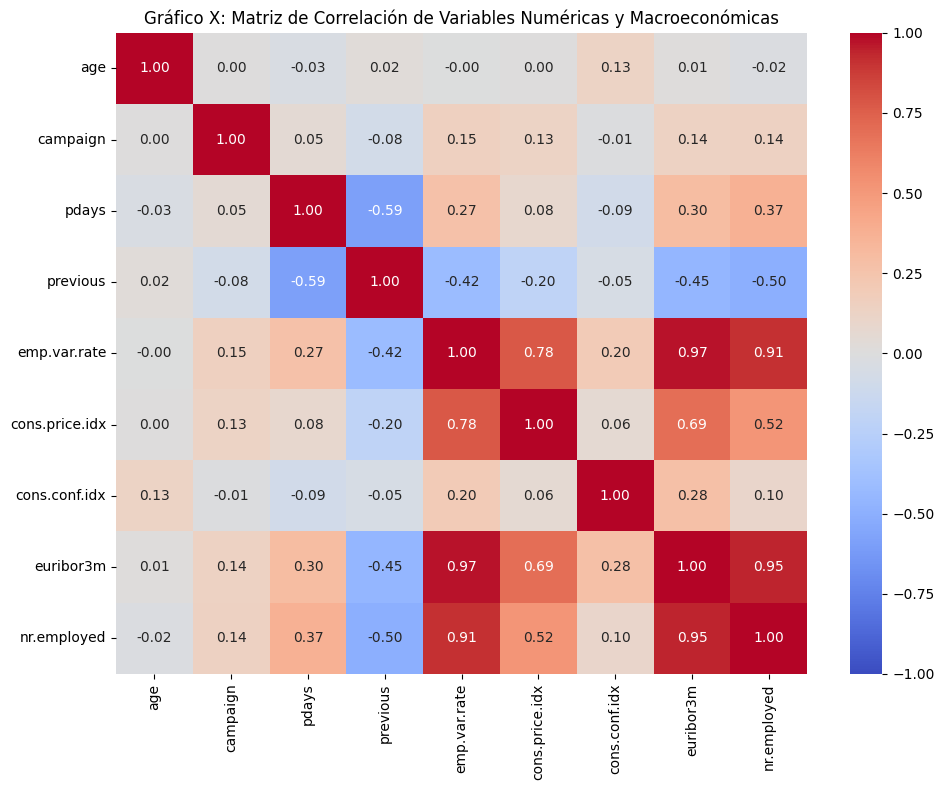

In [169]:
import numpy as np
import matplotlib.pyplot as plt


variNum = ['age', 'campaign', 'pdays', 'previous',
                      'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

# Definir matriz con correlacion de pearson para ver como actuan las variables si una sube o baja
matriz_corr = df_clean[variNum].corr(method='pearson')
plt.figure(figsize=(10, 8))

# Grafico de Matriz
sns.heatmap(
    matriz_corr,
    cmap='coolwarm',       # Paleta de colores
    vmax=1, vmin=-1,       # Limites de escala
    annot=True,            # Muestra los números de correlacion
    fmt=".2f"              # Redondea a 2 decimales
)

plt.title('Gráfico X: Matriz de Correlación de Variables Numéricas y Macroeconómicas')
plt.tight_layout()
plt.show()

Ya que hay variables con una fuerte relacion , se eliminaran las que esten sobre 0.9, ya que al tener una relacion muy fuerte son redundantes entre si

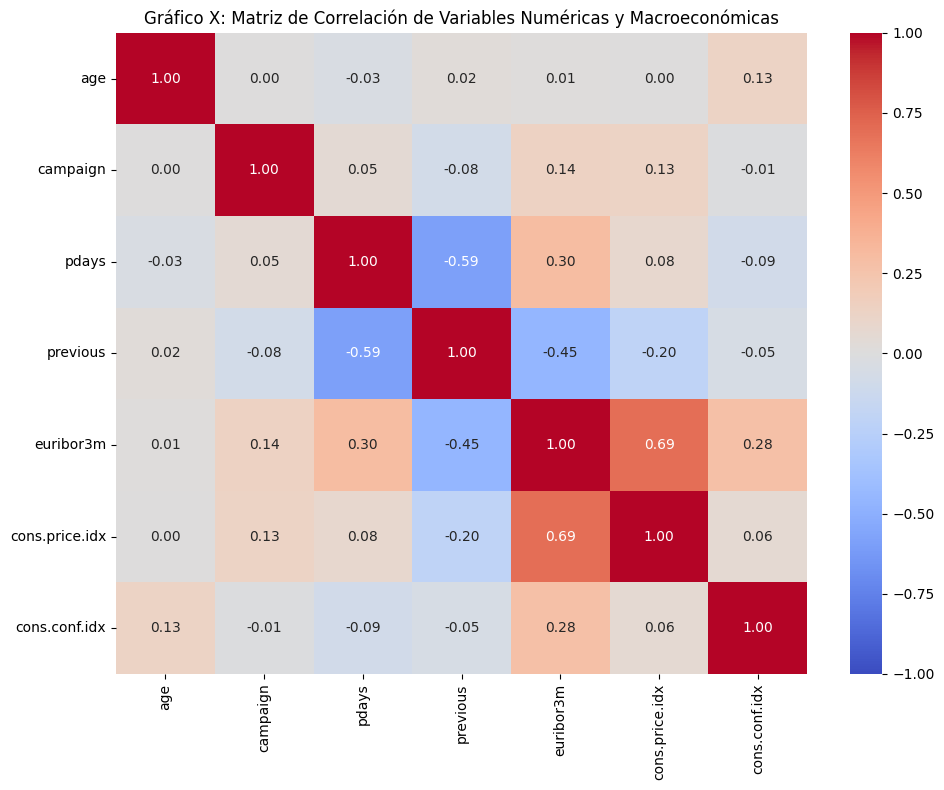

In [170]:
import numpy as np
import matplotlib.pyplot as plt

df_engi = df_clean.copy()
df_engi = df_engi.drop(columns=['emp.var.rate', 'nr.employed'])

variNum = ['age', 'campaign', 'pdays', 'previous',
          'euribor3m', 'cons.price.idx', 'cons.conf.idx']

# Definir matriz con correlacion de pearson para ver como actuan las variables si una sube o baja
matriz_corr = df_engi[variNum].corr(method='pearson')
plt.figure(figsize=(10, 8))

# Grafico de Matriz
sns.heatmap(
    matriz_corr,
    cmap='coolwarm',       # Paleta de colores
    vmax=1, vmin=-1,       # Limites de escala
    annot=True,            # Muestra los números de correlacion
    fmt=".2f"              # Redondea a 2 decimales
)

plt.title('Gráfico X: Matriz de Correlación de Variables Numéricas y Macroeconómicas')
plt.tight_layout()
plt.show()

In [171]:
df_clean = df_clean.drop(columns=['emp.var.rate', 'nr.employed'])

In [172]:
# Variables Cualitativas ordinales
# Ya que las siguientes variables cualitativas si tienen un orden jerarquico, se utiliza OrdinalEncoder
# para darles un orden , asignandoles valores de 0 a N que es lo que hace ordinalEncoder segun el orden asignado,
# haciendo que un valor tenga mas peso que otro segun el orden jerarquico en las variables
# Educacion tiene un orden jerarquico desde analfabeto a titulo universitario
# Dia de la semana, tiene el clasico orden jerarquico de luneas a viernes, no tiene ni sabado ni domingo
ordinal = ['education', 'day_of_week']

ordEdu = ['illiterate', 'basic.4y', 'basic.6y', 'basic.9y',
          'high.school', 'professional.course', 'university.degree'] # Orden de education

ordMonth = ['mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec'] # Orden de month

ordDay = ['mon', 'tue', 'wed', 'thu', 'fri'] # Orden day_of_week


ordCodifi = OrdinalEncoder(
  categories=[ordEdu, ordDay]
  )

# Variables usadas para predecir "y"
features = ['age', 'campaign', 'pdays', 'previous',
            'cons.price.idx', 'cons.conf.idx', 'euribor3m',
            'education', 'day_of_week', 'anio']

df_mode = df_clean.drop(columns=['month']).copy()
df_mode[['education', 'day_of_week']] = ordCodifi.fit_transform(df_mode[['education', 'day_of_week']])

df_modelo, df_predi = train_test_split(
    df_mode,               # DataSet ya limpio
    test_size=0.10,         # Guarda el 10% de la data para luego predecir
    random_state=42,
    stratify=df_mode['y']  # Separa los datos de forma uniforme
)

df_train, df_test = train_test_split(
    df_modelo,              # DataSet destinado al modelo
    test_size=0.30,         # Guarda el 30% de la data para entrenar
    random_state=42,
    stratify=df_modelo['y'] # Separa los datos de forma uniforme
)

print(f"\nEntrenamiento: {len(df_train)}\nTesteo: {len(df_test)}\nPredicciones: {len(df_predi)}")

X_train = df_train[features] # features para entrenar
y_train = df_train['y']  # target para entrenar

X_test = df_test[features] # features para testear
y_test = df_test['y']  # target para testear

# Creacion de modelo de randomForestClasifier
modelo_rf = RandomForestClassifier(
    n_estimators=100    # 100 arboles
    , random_state=42
    )

modelo_rf.fit(X_train, y_train) # Se entrena el randomForest con las features y el target destinados a entrenamiento

y_pred = modelo_rf.predict(X_test) # El modelo intenta predecir el target usando las features destinadas a testeo

print("\n--- Matriz de confusion ---")
print(confusion_matrix(y_test, y_pred)) # Matriz usando el target que se uso en test y en prediccion

print("\n--- Reporte de clasificacion ---")
print(classification_report(y_test, y_pred)) # Reporte usando el target que se uso en test y en prediccion

# El modelo predice la probabilidad con x_test de que el target sea yes
# Ya que solo se toma la columna en la posicion 1
y_proba = modelo_rf.predict_proba(X_test)[:, 1]  # Probabilidad de prediccion usando todas las filas de la
                                                # columna en la posicion 1, usando los datos de X_test
# Calcula la probabilidad de exito comparando
# el tarhet destinado a testeo y el que predijo el modelo
auc_score = roc_auc_score(y_test, y_proba)

print(f"\nAUC: {round(auc_score, 3)}")
print(f"\nAUC de los anteriores modelos: {aucModelAnteri}")


Entrenamiento: 25948
Testeo: 11121
Predicciones: 4119

--- Matriz de confusion ---
[[9431  437]
 [ 851  402]]

--- Reporte de clasificacion ---
              precision    recall  f1-score   support

          no       0.92      0.96      0.94      9868
         yes       0.48      0.32      0.38      1253

    accuracy                           0.88     11121
   macro avg       0.70      0.64      0.66     11121
weighted avg       0.87      0.88      0.87     11121


AUC: 0.759

AUC de los anteriores modelos: 0.762


Es normal que baje el AUC, ya que el tener variables que actuen de forma similar unas con otras puede probocar Data Leakage, o meter ruido, guiandose mas por esas 2 columnas, en vez de usar 1, que con la fuerte relacion que tienen, esa columna da un aporte similar al de la otra columna

## Referencias

Librerias usadas

In [173]:
# Bibliotecas generales
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Escalado y codificacion de datos
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler

# IterativeImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import ExtraTreesRegressor

# Creacion del modelo randomForest
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

El DataSet es :
<br>bank-additional-full, obtenido de la evaluacion 2
<br>Link de dataSet : http://archive.ics.uci.edu/ml/datasets/Bank+Marketing de bank marketing
<br>El dataSet recopila información de
campañas de marketing realizadas entre mayo de 2008 y noviembre de 2010